Using TokaMaker to predict currents and forces induced during a CQ in ITER
==========
The purpose of this notebook is to a demonstrate prediction of eddy currents and forces during a disruption for the ITER tokamak in TokaMaker. It demonstrates concepts related to:
 - Computing an inverse equilibrium with specified targets
 - Performing a time-dependent simulation with eddy currents
 - Evaluating integrals of fields to compute forces from eddy currents

Additional examples can be found as part of the documentation here: [https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/latest/doc_gs_main.html](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/latest/doc_gs_main.html)

## Setup Python environment

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

To load the TokaMaker python module we need to tell python where to the module is located. The best way to do this is through the `PYTHONPATH` environment variable or using a dedicated environement variable (eg. `OFT_ROOTPATH`) to provide the path to where the OpenFUSIONToolkit is installed and passing this to `sys.path.append()` as below.

It is also possible to run this script on Google Colab, which requires a few other steps including installing OFT from a binary tarball.

In [ ]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    on_google_colab = True
except:
    tokamaker_python_path = os.getenv('OFT_ROOTPATH')
    if tokamaker_python_path is not None:
        sys.path.append(os.path.join(tokamaker_python_path,'python'))
    on_google_colab = False
    pass
else:
    !pip install -q wurlitzer ipympl
    OFT_package = 'OpenFUSIONToolkit_v1.0.0-beta7-Linux-GNU-x86_64'
    OFT_tarball = 'OpenFUSIONToolkit_v1.0.0-beta7-Ubuntu_22_04-GNU-x86_64.tar.gz'
    print("Google collab detected:")
    if os.path.exists(os.path.join('/content',OFT_package,'python')):
        print("  Using existing OFT installation")
    else:
        print("  Installing OFT from GitHub")
        !wget -q https://github.com/openfusiontoolkit/OpenFUSIONToolkit/releases/download/v1.0.0-beta7/{OFT_tarball}
        !tar xzf {OFT_tarball}
    OFT_rootpath = os.path.join('/content',OFT_package)
    !cp {OFT_rootpath}/examples/TokaMaker/ITER/ITER_mesh.h5 .
    sys.path.append(os.path.join(OFT_package,'python'))
    %load_ext wurlitzer
%matplotlib inline
%config InlineBackend.figure_format = "retina"

Now that TokaMaker is installed an in our Python path we can load the required modules

In [3]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun, compute_forces_components

## Setup model

### Initialize TokaMaker object
We now create a [OFT_env](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1__core_1_1OFT__env.html) instance for execution using two threads (one thread on colab) and a [TokaMaker](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html) instance to use for equilibrium calculations.

The `myOFT` instance is used to manage toolkit-wide environment elements and is passed to initialize individual physics tools such as TokaMaker or ThinCurr.

In [4]:
if on_google_colab:
    myOFT = OFT_env(nthreads=1)
else:
    myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    HEAD_detached_at_v1.0.0-beta7
Revision id:           b19540a4
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/52/n5qxh27n4w19qxzqygz2btbw0000gn/T/oft_61536/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Setup TokaMaker with CUTE mesh
Now we load the mesh generated in the [Building a mesh for ITER example](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/doc_tMaker_ITER_ex1.html) using [load_gs_mesh()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/namespaceOpenFUSIONToolkit_1_1TokaMaker_1_1meshing.html#aacb0f0d4ad8131d17461b7019dcd888f) and [setup_mesh](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html#a2f000ca8760eb886b9439ad30026c8d1). Next the [setup_regions()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html#ad16d5039d91afc584a7c96dff8c8e1ed) method is used to define the different region types and corresponding physics, by passing the conductor and coil dictionaries for the mesh. Finally, we call [setup()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html#aaa9d13419da15fd024f845b705ba94a8) to setup the required matrices and solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through $F_0$ = $B_0$*$R_0$, where $B_0$ (5.3 T) is the toroidal field at a reference location $R_0$ (6.2 m).

In [5]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order = 2, F0 = 5.3*6.2)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.1000000000000001E-003


### Plot machine and computational mesh
After the previous series of calls the finite element representation is now initialized and linear operators (matrics) are computed corresponding to the desired physics equations in each region.
$$
\Delta^* \psi =
\begin{cases}
    -\frac{1}{2}\frac{\partial F^2}{\partial \psi} - \mu_0 R^2 \frac{\partial P}{\partial \psi} & \text{if } \textbf{r} \in \mathcal{P}\\
    -R \mu_0 J_{\phi} & \text{if } \textbf{r} \in \color{blue}{\mathcal{S}},\color{red}{\mathcal{C}} \\
    0 & \color{gray}{\text{elsewhere}}
\end{cases}
$$

This system is nonlinear in $\psi$ and is solved using a Picard (fixed-point) iteration for the first part of this example. Linear operators (eg. $\Delta^*$) are inverted using a sparse LU factorization package (eg. [UMFPACK](https://people.engr.tamu.edu/davis/suitesparse.html)).

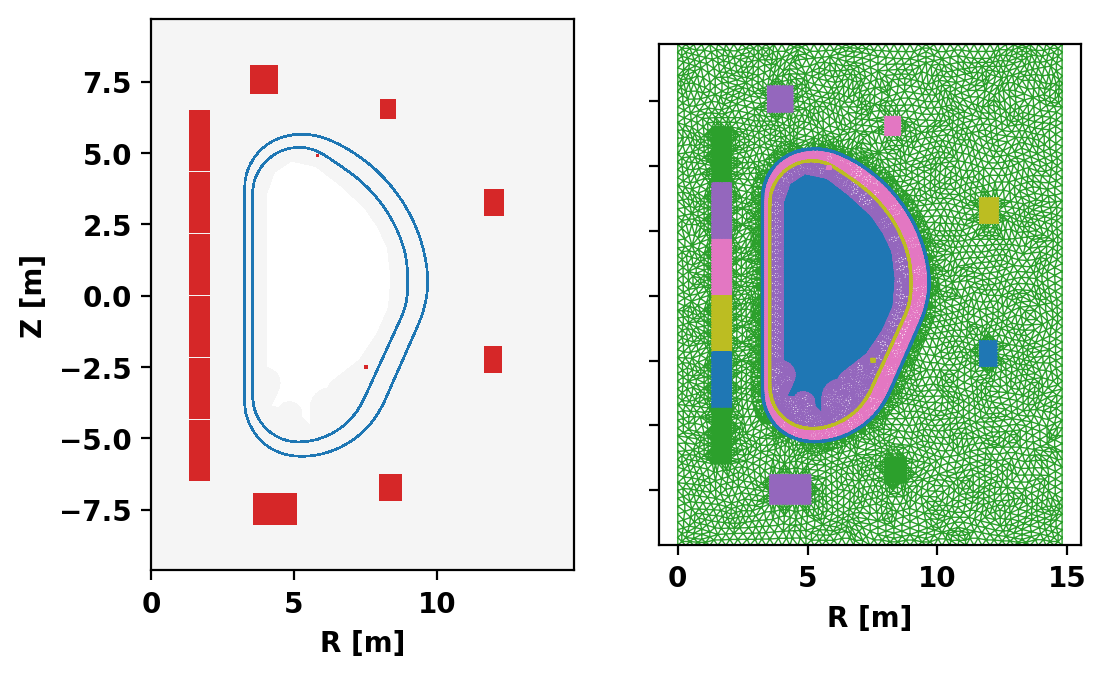

In [6]:
fig, ax = plt.subplots(1,2,sharey=True)
mygs.plot_machine(fig,ax[0],limiter_color=None,coil_color='tab:red',cond_color='tab:blue')
for i in range(mygs.reg.max()):
    ax[1].triplot(mygs.r[:,0],mygs.r[:,1],mygs.lc[mygs.reg==i+1,:],lw=0.5)
ax[1].set_aspect('equal','box')
ax[0].set_ylabel('Z [m]')
ax[0].set_xlabel('R [m]')
_ = ax[1].set_xlabel('R [m]')

## Compute pre-CQ equilibrium
Now we compute the same equilibrium as in the [Baseline L-mode scenario for ITER](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/doc_tMaker_ITER_ex2.html) included in the TokaMaker examples.

In [7]:
# Define hard limits on coil currents
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

# Define global targets
Ip_target=15.6E6
P0_target=6.2E5
mygs.set_targets(Ip=Ip_target, pax=P0_target)

# Define shape targets
isoflux_pts = np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
x_point = np.array([[5.125, -3.4],])
mygs.set_isoflux(np.vstack((isoflux_pts,x_point)))
mygs.set_saddles(x_point)

# Set coil regularization matrix
regularization_terms = []
for name, coil in mygs.coil_sets.items():
    if name.startswith('CS'):
        if name.startswith('CS1'):
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=2.E-2))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    elif name.startswith('PF'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    elif name.startswith('VS'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E2))
mygs.set_coil_reg(reg_terms=regularization_terms)

# Set F*F' and P' profiles
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

# Compute equilibrium
R0 = 6.3
Z0 = 0.5
a = 2.0
kappa = 1.4
delta = 0.0
mygs.init_psi(R0, Z0, a, kappa, delta)
mygs.solve()
psi_full = mygs.get_psi(normalized=False)
psi_lim = mygs.psi_bounds[0]

Starting non-linear GS solver
     1  1.3649E+01  1.0140E-01  1.1822E-01  6.3991E+00  5.2233E-01 -2.5883E-15
     2  1.8193E+01  8.2304E-02  6.7616E-02  6.3850E+00  5.2584E-01  1.8981E-14
     3  2.0446E+01  7.4811E-02  5.5986E-02  6.3756E+00  5.2790E-01 -2.4158E-14
     4  2.1636E+01  7.1387E-02  3.7106E-02  6.3700E+00  5.2939E-01  4.1413E-14
     5  2.2284E+01  6.9682E-02  2.2606E-02  6.3667E+00  5.3044E-01  2.7609E-14
     6  2.2641E+01  6.8789E-02  1.3312E-02  6.3649E+00  5.3118E-01  2.4158E-14
     7  2.2841E+01  6.8307E-02  7.7236E-03  6.3638E+00  5.3170E-01 -1.7256E-14
     8  2.2953E+01  6.8041E-02  4.4497E-03  6.3632E+00  5.3206E-01 -3.1060E-14
     9  2.3017E+01  6.7893E-02  2.5553E-03  6.3628E+00  5.3231E-01  2.7609E-14
    10  2.3053E+01  6.7810E-02  1.4656E-03  6.3627E+00  5.3248E-01  6.9022E-15
    11  2.3073E+01  6.7764E-02  8.4070E-04  6.3625E+00  5.3260E-01 -4.1413E-14
    12  2.3084E+01  6.7737E-02  4.8271E-04  6.3625E+00  5.3267E-01  2.0707E-14
    13  2.3091E+01  6.

### Print information and plot equilibrium
Flux surfaces of the computed equilibrium can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi()" method. The additional plotting methods \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_machine "plot_machine()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_constraints "plot_constraints()" are also used to show context and other information. Each method has a large number of optional arguments for formatting and other options.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.5600E+07
  Current Centroid [m]    =    6.203  0.530
  Magnetic Axis [m]       =    6.362  0.533
  Elongation              =    1.873 (U:  1.763, L:  1.982)
  Triangularity           =    0.472 (U:  0.404, L:  0.539)
  Plasma Volume [m^3]     =   820.079
  q_0, q_95               =    0.823  2.760
  Plasma Pressure [Pa]    =   Axis:  6.1922E+05, Peak:  6.1922E+05
  Stored Energy [J]       =    2.4299E+08
  <Beta_pol> [%]          =   42.4358
  <Beta_tor> [%]          =    1.7801
  <Beta_n>   [%]          =    1.1953
  Diamagnetic flux [Wb]   =    1.5403E+00
  Toroidal flux [Wb]      =    1.2187E+02
  l_i                     =    1.1530

Coil Currents [MA]:
  CS3U:           13.74
  CS2U:            9.74
  CS1U:           -9.06
  CS1L:           -8.81
  CS2L:           13.40
  CS3L:           17.88
  PF1:            12.94
  PF2:            -2.20
  PF3:            -5.95
  PF4:            -5.14

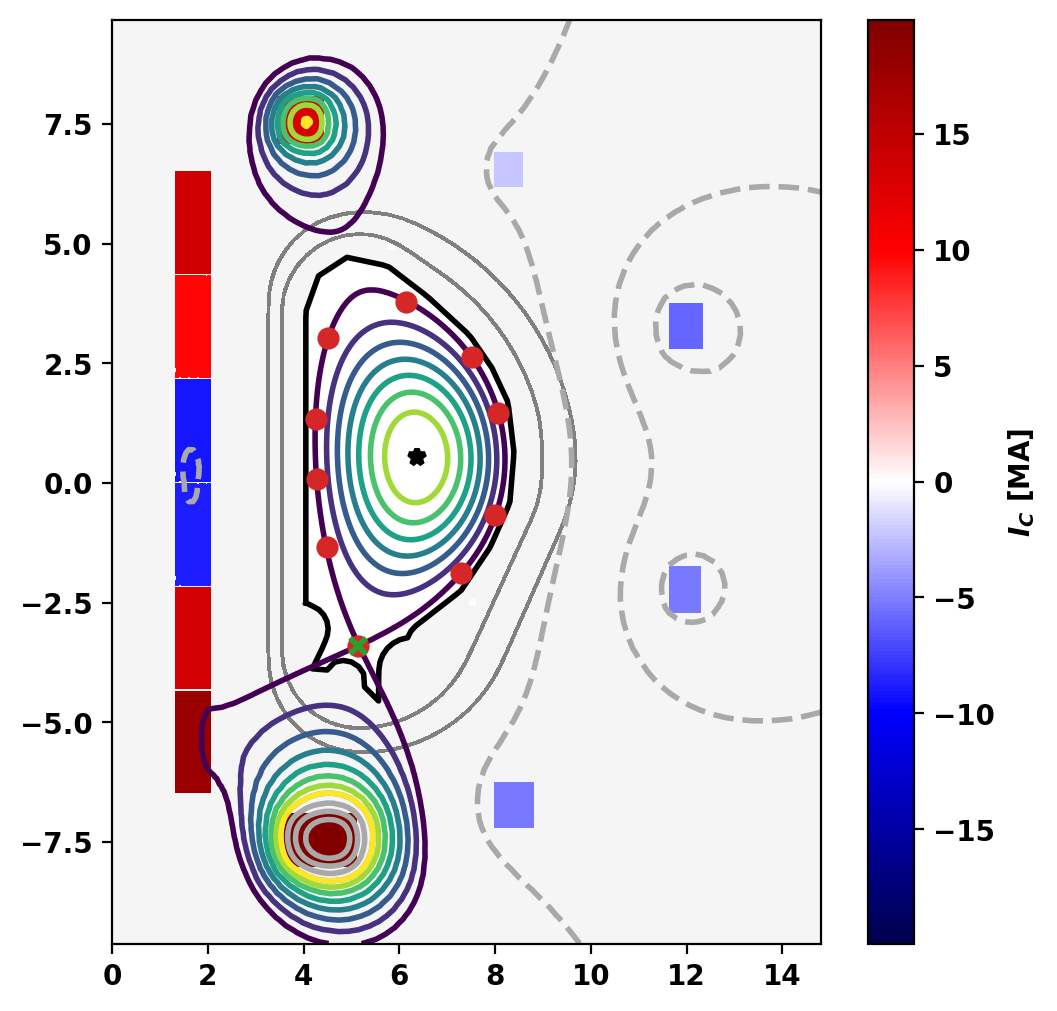

In [8]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,xpoint_color=None,vacuum_nlevels=4)
mygs.plot_constraints(fig,ax,isoflux_color='tab:red',isoflux_marker='o')

mygs.print_info()
print()
print("Coil Currents [MA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    print('  {0:10} {1:10.2F}'.format(key+":",current/1.E6))

## Compute eddy currents and forces for a simple current quench
TokaMaker can be used to evaluate some of the impacts caused by the Current Quench (CQ) that occurs following a disruption in tokamaks. During the CQ the plasma current rapidly falls due to high resistivity following the thermal quench. In real CQs the plasma current profile significantly evolves during this quench, due to changes in pressure and temperature profiles and plasma motions, such as VDEs. However, for first order approximation we can model the eddy currents and voltages produced by the CQ by simply decreasing the flux corresponding to the plasma current over a given timescale.

### Extract flux from plasma current only
To do this we first need to separate the flux corresponding to the plasma current, which changes during the CQ, from the vacuum flux produced by the coils, which does not change (if the coil currents remain fixed) over the CQ. This can be done by performing a [vacuum solve](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html) to get the vacuum flux from the coils and then subtracting this from the full flux to isolate the plasma contribution.

**Note:** This is meant to act as a first order model of inductive CQ impacts and additional effects related to the detailed evolution of the plasma current, coil currents, and other dynamics will be important for detailed analysis and/or predicitons.

   1  4.2217E+06


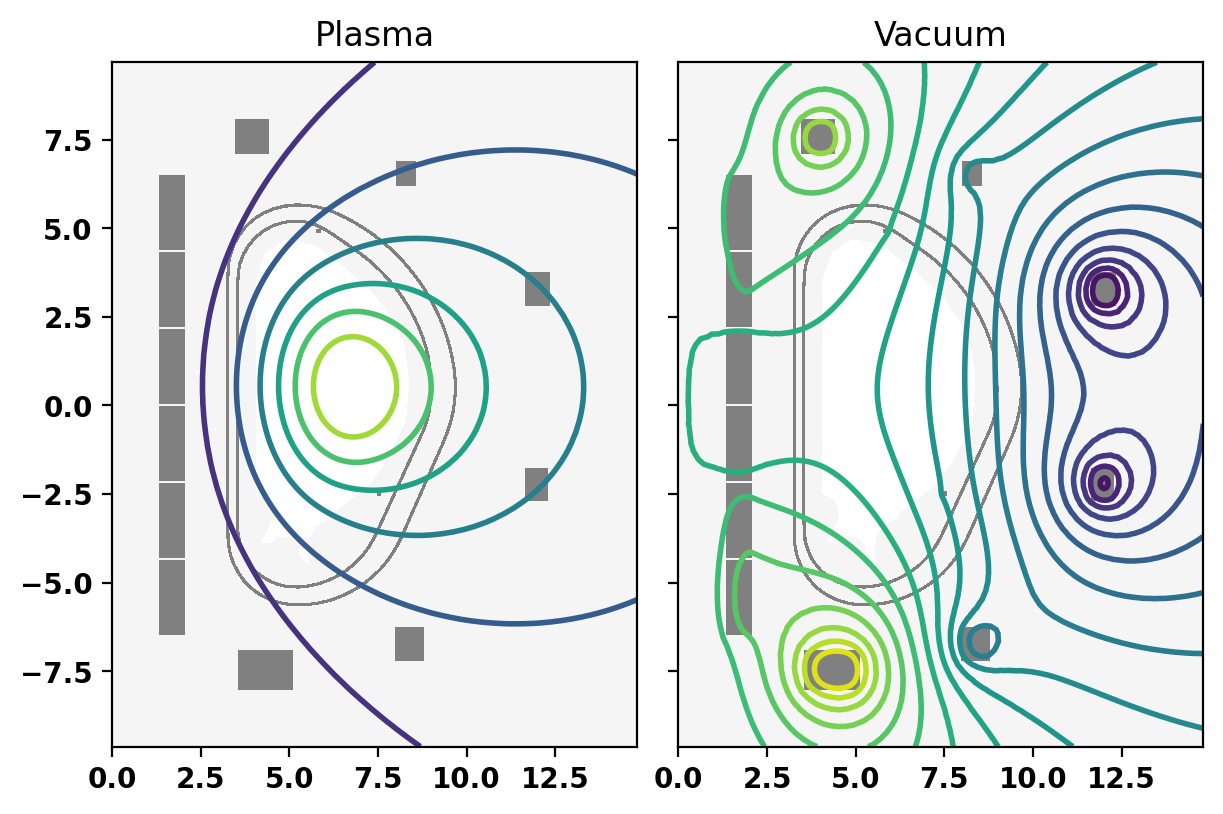

In [9]:
# Compute flux from coils only
mygs.set_psi(0.0*psi_full)
psi_vac = mygs.vac_solve()
# Subtract to yield flux from plasma current
psi_plasma = psi_full-psi_vac
# Save coil currents
coil_currents, _ = mygs.get_coil_currents()

# Plot isolated plasma flux
fig, ax = plt.subplots(1,2,sharey=True,constrained_layout=True)
mygs.plot_machine(fig,ax[0],limiter_color=None)
mygs.plot_psi(fig,ax[0],psi_plasma,normalized=False,xpoint_color=None,opoint_color=None)
ax[0].set_title('Plasma')
mygs.plot_machine(fig,ax[1],coil_colormap=None,limiter_color=None)
mygs.plot_psi(fig,ax[1],psi=psi_vac,normalized=False,plasma_nlevels=20,vacuum_levels=None,xpoint_color=None,opoint_color=None)
_ = ax[1].set_title('Vacuum')

### Perform time-dependent simulation with plasma-current quench source
With the flux separated into constituent components a time-dependent simulation may now be performed to compute the evolution of eddy current in conducting structures in response to the loop voltage generated by the CQ. For the initial period of the simulation, during the CQ, a voltage source is added to the solution by adding the change in flux from the plasma current quench to the RHS of the solve via [set_psi_dt()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html). Additionally, a longer timestep is used following the CQ as the dynamics should then evolve over longer timescales dictated by the conductor's L/R times.

In [10]:
# Set linear CQ time
CQ_time = 20.0E-3

# Setup simulation
psi_last = np.zeros((mygs.np))
t = 0.0
dt = CQ_time/20.0
results = [psi_vac+psi_plasma]
sim_time = [0.0]
mygs.settings.pm=False
mygs.update_settings()
mygs.set_coil_currents()
for i in range(100):
    if i == 40:
        dt = CQ_time/5.0
    # Set source from last time step w/ or w/o CQ source
    if t <= CQ_time:
        mygs.set_psi_dt(psi_plasma*dt/CQ_time+psi_last,dt)
    else:
        mygs.set_psi_dt(psi_last,dt)
    
    # Compute next time step
    mygs.set_psi(0.0*psi_last) # Necessary temporarily to initialize zero flux for vacuum solves
    psi_last = mygs.vac_solve()
    t += dt
    
    # Save timestep for plotting
    results.append(psi_vac+psi_last+psi_plasma*max(0.0,1.0-t/CQ_time))
    sim_time.append(t)
# Convert to NumPy array
sim_time = np.array(sim_time)

# Get index of sampling times
ind_sample = (abs(sim_time-CQ_time/2.0)).argmin()
ind_sample2 = (abs(sim_time-CQ_time*2.0)).argmin()

### Plot results
Following the calculation we can plot the evolution of $\psi$ in the volume and $J_{\phi}$ in the vacuum vessel at the midpoint of the CQ. A large eddy current is generated in the VV with some inboard-outboard assymetry and assymetry between the inner and outer VVs.

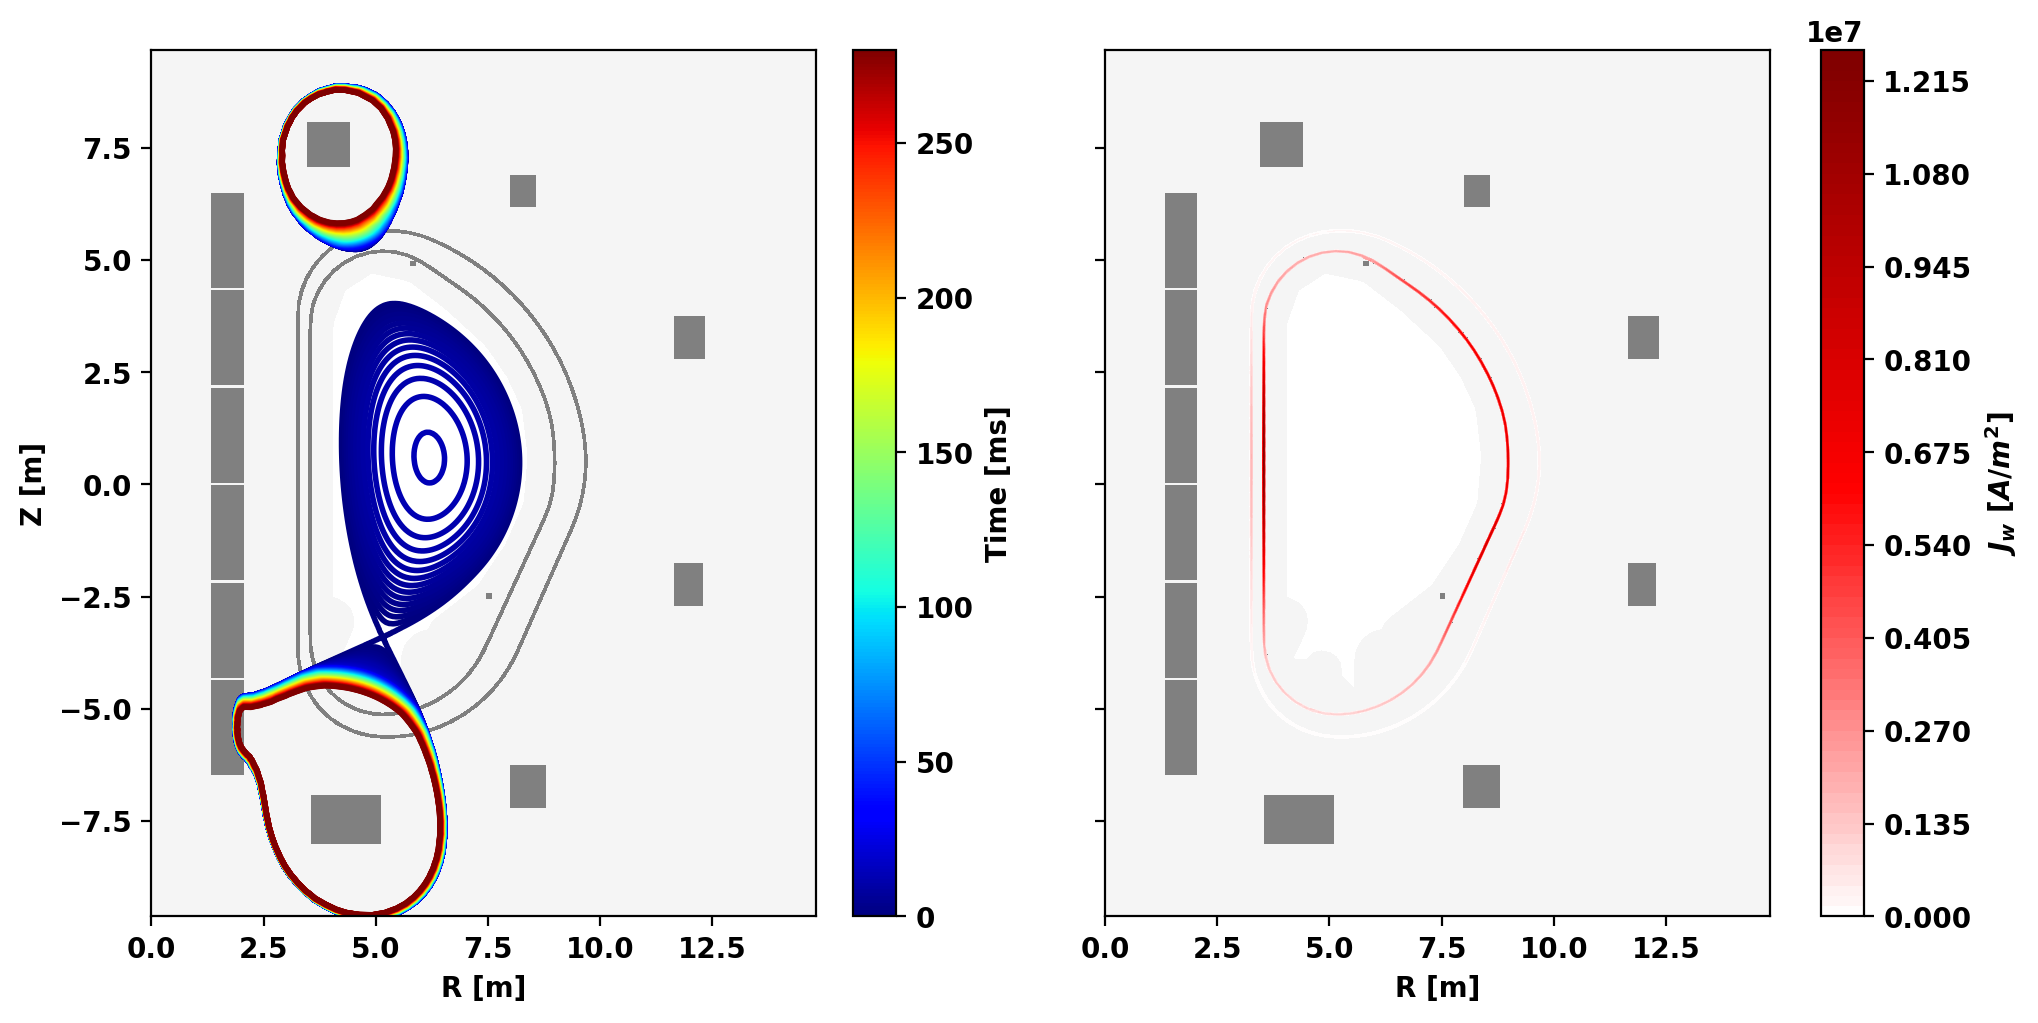

In [11]:
fig, ax = plt.subplots(1,2,sharey=True,figsize=(10,5),constrained_layout=True)

# Plot flux evolution in time
mygs.plot_machine(fig,ax[0],coil_colormap=None,limiter_color=None)
colors = plt.cm.jet(sim_time/sim_time[-1]) #np.linspace(0.0, sim_time[-1], len(results)))
for i, result in enumerate(results):
    mygs.plot_psi(fig,ax[0],psi=result,normalized=False,plasma_levels=[psi_lim],plasma_color=[colors[i]],vacuum_levels=None,xpoint_color=None,opoint_color=None)
norm = mpl.colors.Normalize(vmin=0.0, vmax=sim_time[-1]*1.E3)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.jet),ax=ax[0],label='Time [ms]')

# Plot snapshot at t=10 ms
mygs.plot_machine(fig,ax[1],coil_colormap=None,limiter_color=None)
mygs.plot_eddy(fig,ax[1],psi=results[ind_sample],colormap='seismic',symmap=True,nlevels=100)

# Format plots
ax[0].set_ylabel('Z [m]')
ax[0].set_xlabel('R [m]')
_ = ax[-1].set_xlabel('R [m]')

### Plot loop voltage
We can also do the same thing for the loop voltage, which is an important consideration for disruption impacts as well as it can lead to arcing and/or damage to electrical systems near the device. In this case we can see that voltages in excess of 1 kV are generated inside the VV. For this plot the plasma region is masked out so that we do not see the large voltages inside the plasma that are not relevant for wall or device-mounted components.

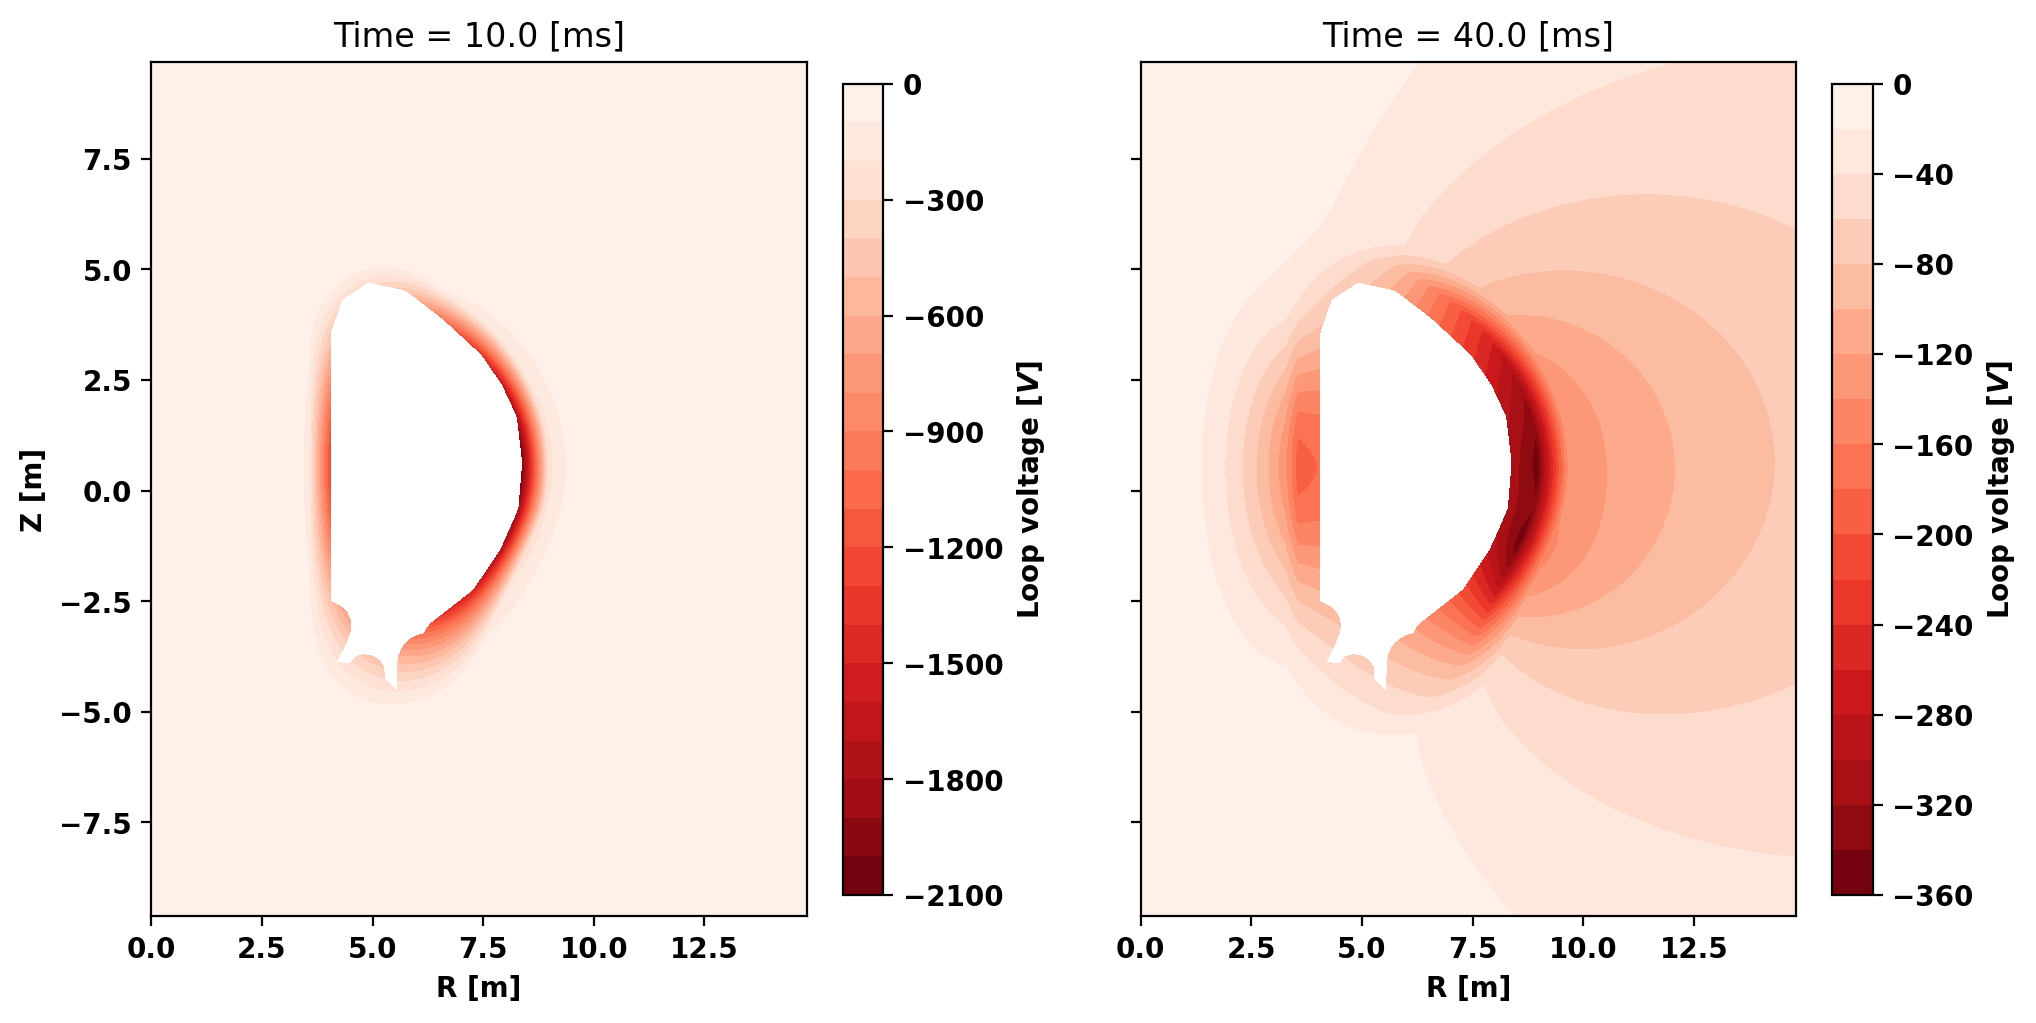

In [12]:
fig, ax = plt.subplots(1,2,figsize=(10,5),sharey=True,constrained_layout=True)

region_mask = (mygs.reg!=1)

# Plot at t = 10 ms
dpsi_dt = (results[ind_sample+1]-results[ind_sample-1])/(sim_time[ind_sample+1]-sim_time[ind_sample-1])
clf = ax[0].tricontourf(mygs.r[:,0],mygs.r[:,1],mygs.lc[region_mask,:],2.0*np.pi*dpsi_dt,levels=20,cmap='Reds_r')
fig.colorbar(clf,ax=ax[0],label=r'Loop voltage [$V$]', shrink=0.95)
ax[0].set_title('Time = {0:.1f} [ms]'.format(sim_time[ind_sample]*1.E3))

# Plot at t = 40 ms
dpsi_dt = (results[ind_sample2+1]-results[ind_sample2-1])/(sim_time[ind_sample2+1]-sim_time[ind_sample2-1])
clf = ax[1].tricontourf(mygs.r[:,0],mygs.r[:,1],mygs.lc[region_mask,:],2.0*np.pi*dpsi_dt,levels=20,cmap='Reds_r')
fig.colorbar(clf,ax=ax[1],label=r'Loop voltage [$V$]', shrink=0.95)
ax[1].set_title('Time = {0:.1f} [ms]'.format(sim_time[ind_sample2]*1.E3))

# Format plots
ax[0].set_ylabel('Z [m]')
ax[0].set_xlabel('R [m]')
_ = ax[1].set_xlabel('R [m]')
for ax_tmp in ax:
    ax_tmp.set_aspect('equal','box')

### Compute and plot forces
We can also compute the forces in the conducting wall regions by evaluating $2\pi \int J_{\phi} B_r r dA$ and $2\pi \int J_{\phi} B_z r dA$ over the conducting regions. TokaMaker provides the helper function [compute_forces_components()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/latest/namespaceOpenFUSIONToolkit_1_1TokaMaker_1_1util.html#a16f5f04a88314363e1825e943f83cd3a) to get the required fields for the integral, which can then be fed to [area_integral()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v1.0.0-beta7/classOpenFUSIONToolkit_1_1TokaMaker_1_1__core_1_1TokaMaker.html) to perform the area integral. In this case we compute the force separately over the inner and outer VV.

In [13]:
Fr_inner = np.zeros((len(results),))
Fr_outer = np.zeros((len(results),))
for i, result in enumerate(results):
    mesh_currents, Bv_cond, mask, rcc = compute_forces_components(mygs,results[i])
    Fr_inner[i] = mygs.area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,2],reg_mask=cond_dict['VV1']['reg_id'])
    Fr_outer[i] = mygs.area_integral(mesh_currents*mygs.r[:,0]*Bv_cond[:,2],reg_mask=cond_dict['VV2']['reg_id'])

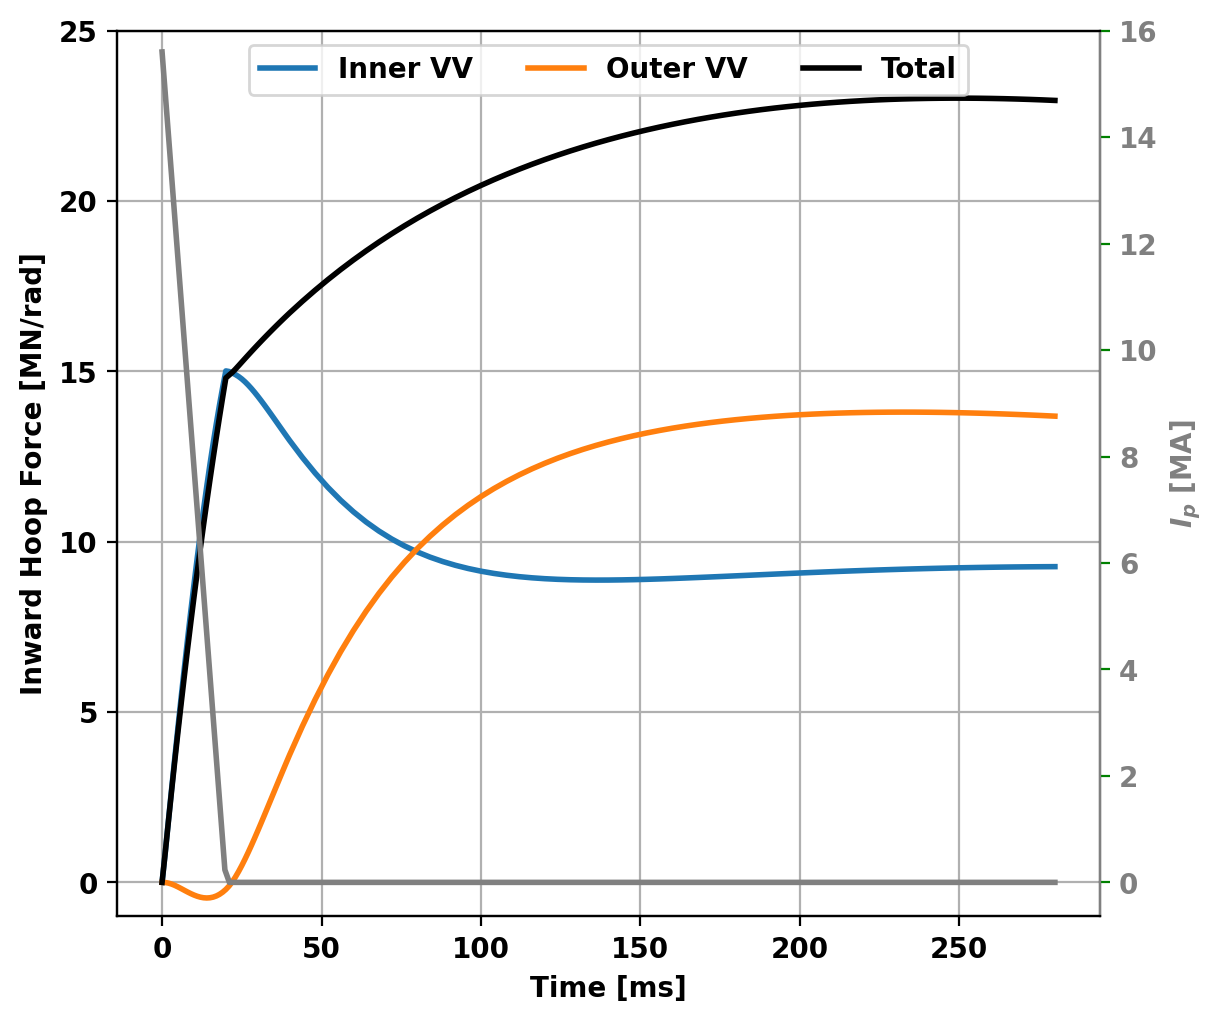

In [14]:
fig, ax = plt.subplots(1,1,figsize=(6,5),constrained_layout=True)

# Plot plasma current
x = np.linspace(0.0,sim_time[-1]*1.E3,200)
y = np.zeros_like(x); y[x<CQ_time*1.E3] = (CQ_time*1.E3-x[x<CQ_time*1.E3])*Ip_target/1.E6/(CQ_time*1.E3)
ax2 = ax.twinx()
ax2.plot(x,y,label=r'$I_P$',color='0.5')

# Plot forces
ax.plot(np.asarray(sim_time)*1.E3,-np.asarray(Fr_inner)/1.E6,label='Inner VV')
ax.plot(np.asarray(sim_time)*1.E3,-np.asarray(Fr_outer)/1.E6,label='Outer VV')
ax.plot(np.asarray(sim_time)*1.E3,-(np.asarray(Fr_inner)+np.asarray(Fr_outer))/1.E6,'k',label='Total')

# Format plot
ax.grid(True)
ax.set_ylim(-1,25)
ax2.set_ylim(-16/25.,16)
ax.legend(loc='upper center',ncol=3)
ax.set_ylabel(r'Inward Hoop Force [MN/rad]')
ax2.set_ylabel(r'$I_p$ [MA]',color='0.5')
ax2.tick_params(color='green', labelcolor='0.5')
ax2.spines['right'].set_edgecolor('0.5')
_ = ax.set_xlabel(r'Time [ms]')

### Create animation of full simulation
Using a helper function that encapsulates the foce calculation we can create and animation of the current and force evolution throughout the simulated current quench.

In [15]:
def plot_CQ(fig, ax, psi, time):
    # Get currents and field in conducting regions
    J_cond, Bv_cond, mask, rcc = compute_forces_components(mygs,psi,cell_centered=True)
    
    # Plot current density
    Jphi = J_cond[mask]
    Jphi /= 1.E6
    vmax = max(1.E0,abs(Jphi).max())
    mygs.plot_psi(fig,ax[0],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf2 = ax[0].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Jphi,cmap='Reds', vmin=0.0, vmax=vmax)
    cb1 = fig.colorbar(clf2,ax=ax[0],label=r'Toroidal Current Density [$MA/m^2$]',format='{x:6.1f}',shrink=0.95)
    
    # Radial force
    Fr = J_cond[mask]*Bv_cond[mask,2]
    Fr /= 1.E6
    vmax = abs(Fr).max()
    mygs.plot_psi(fig,ax[1],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf = ax[1].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Fr,cmap='seismic', vmin=-vmax, vmax=vmax)
    cb2 = fig.colorbar(clf,ax=ax[1],label=r'Radial Force per unit volume [$MN/m^3$]', shrink=0.95)
    
    # Vertical force
    Fz = -J_cond[mask]*Bv_cond[mask,0]
    Fz /= 1.E6
    vmax = abs(Fz).max()
    mygs.plot_psi(fig,ax[2],psi=psi,normalized=False,plasma_levels=[psi_lim],plasma_color=['0.5'],vacuum_levels=None,xpoint_color=None,opoint_color=None)
    clf = ax[2].tripcolor(mygs.r[:,0],mygs.r[:,1],mygs.lc[mask],Fz,cmap='seismic', vmin=-vmax, vmax=vmax)
    cb3 = fig.colorbar(clf,ax=ax[2],label=r'Vertical Force per unit volume [$MN/m^3$]', shrink=0.95)
    
    # Format plots
    fig.suptitle('Time = {0:.1f} [ms]'.format(time*1.E3),fontsize=20)
    ax[0].set_ylabel('Z [m]')
    ax[0].set_xlabel('R [m]')
    _ = ax[1].set_xlabel('R [m]')
    for ax_tmp in ax:
        ax_tmp.set_aspect('equal','box')

    return cb1, cb2, cb3

**Plot snapshots**

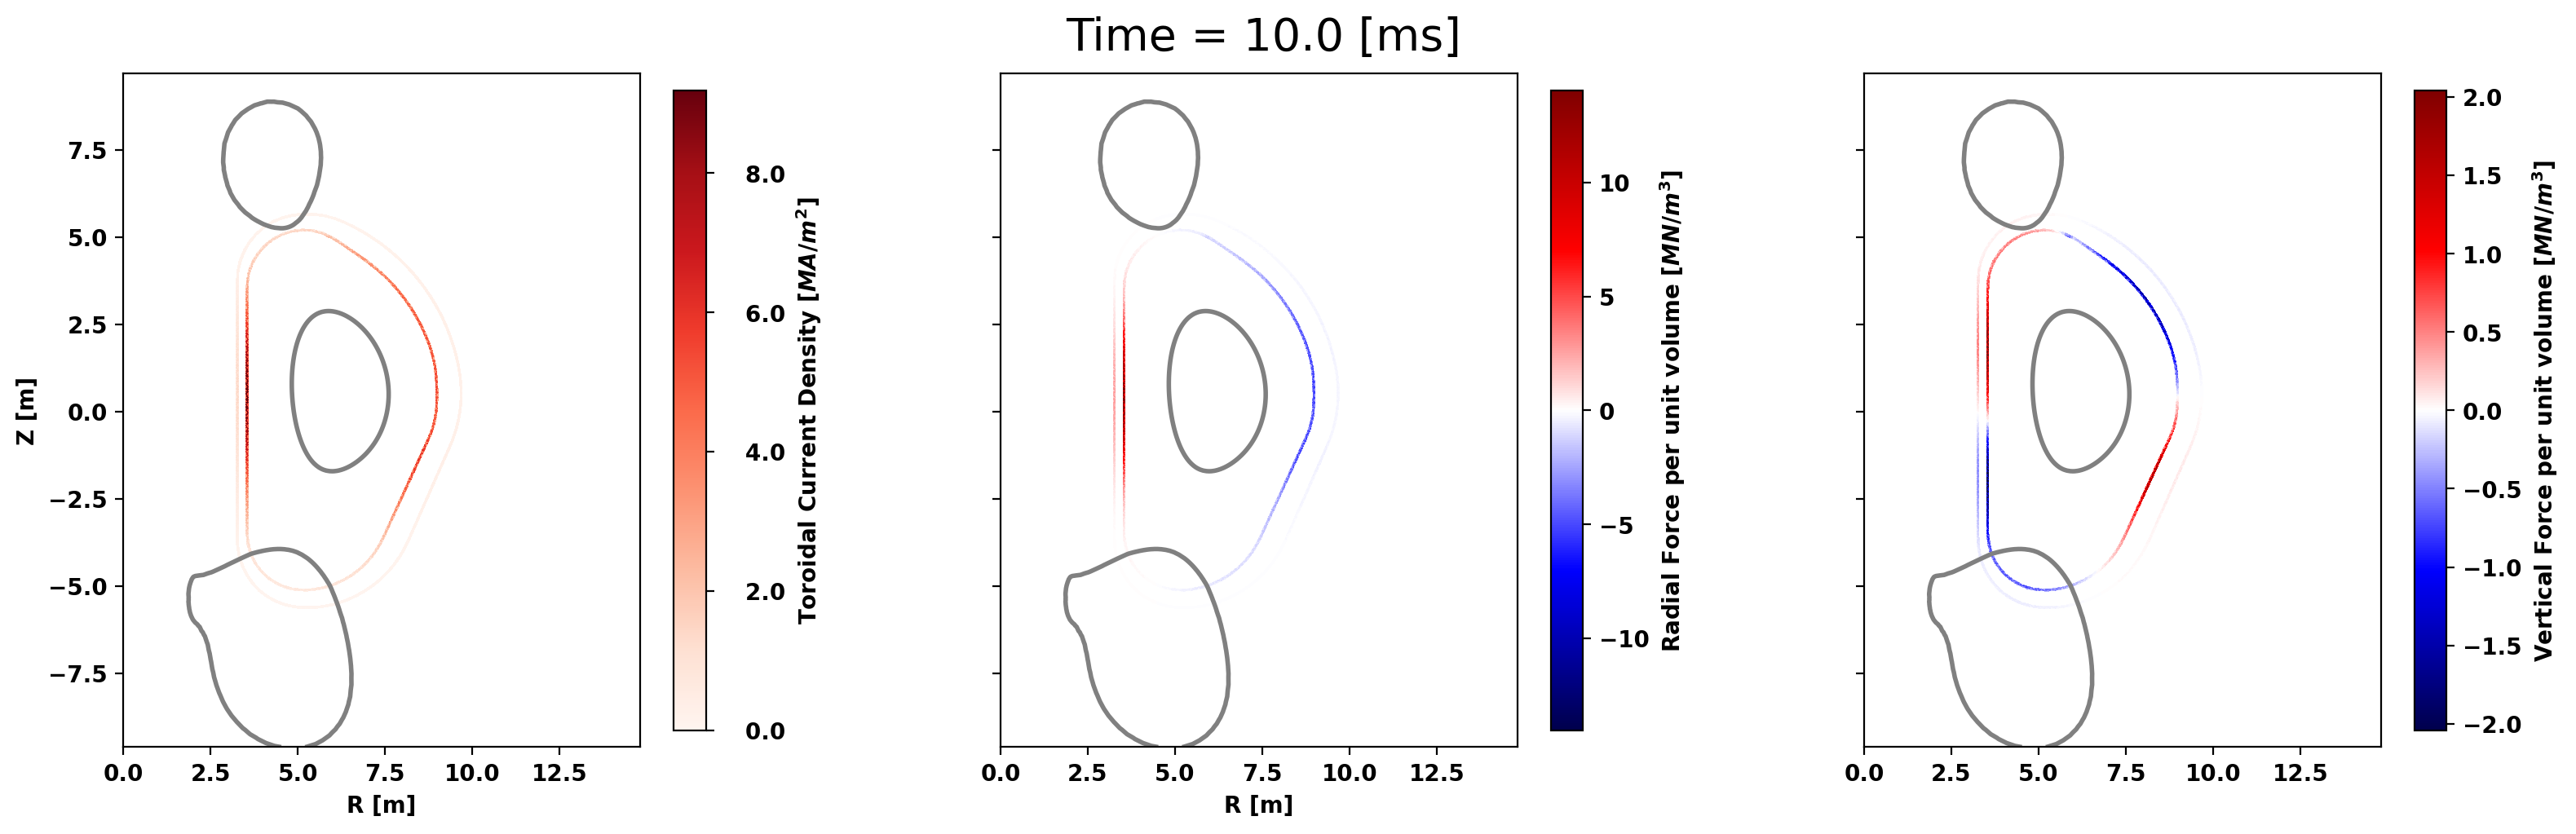

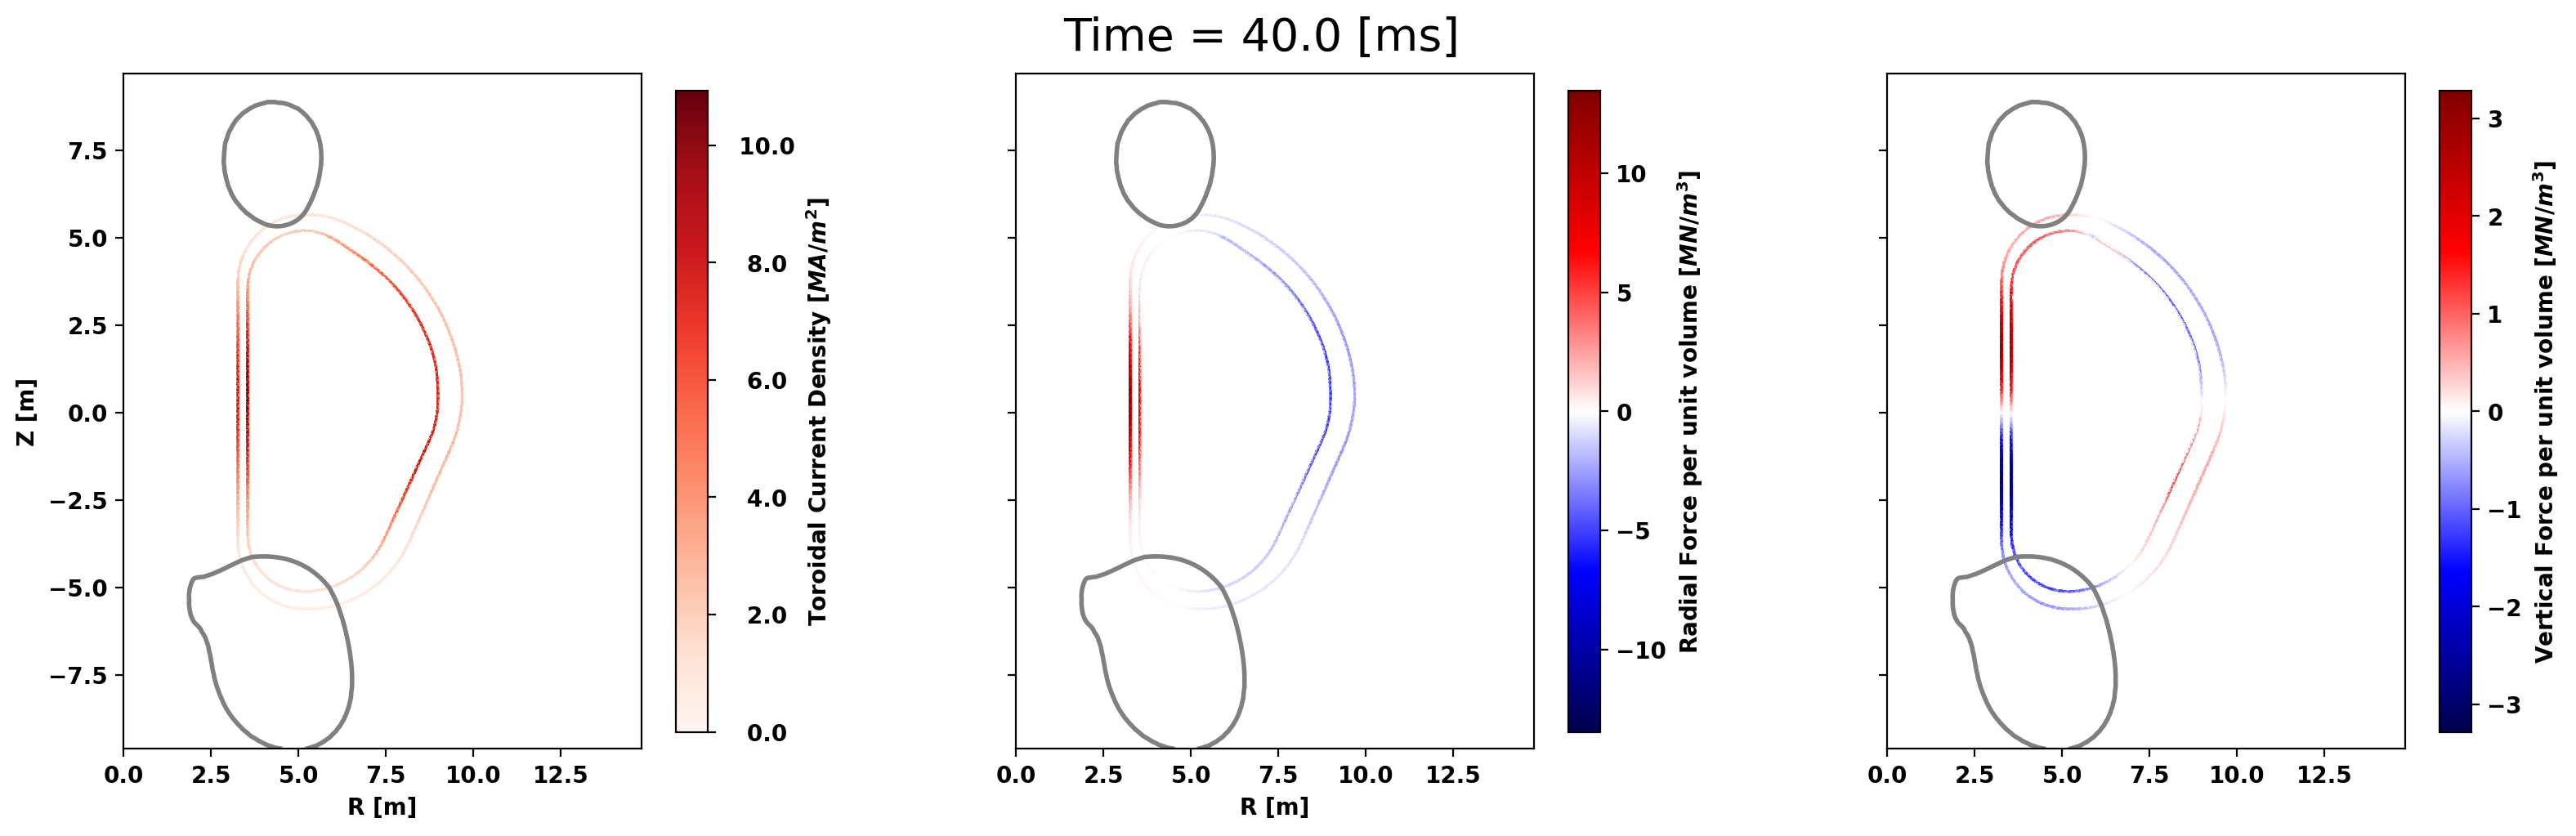

In [16]:
fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
_ = plot_CQ(fig, ax, results[ind_sample], sim_time[ind_sample])

fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
_ = plot_CQ(fig, ax, results[ind_sample2], sim_time[ind_sample2])

**Create animation snapshots**

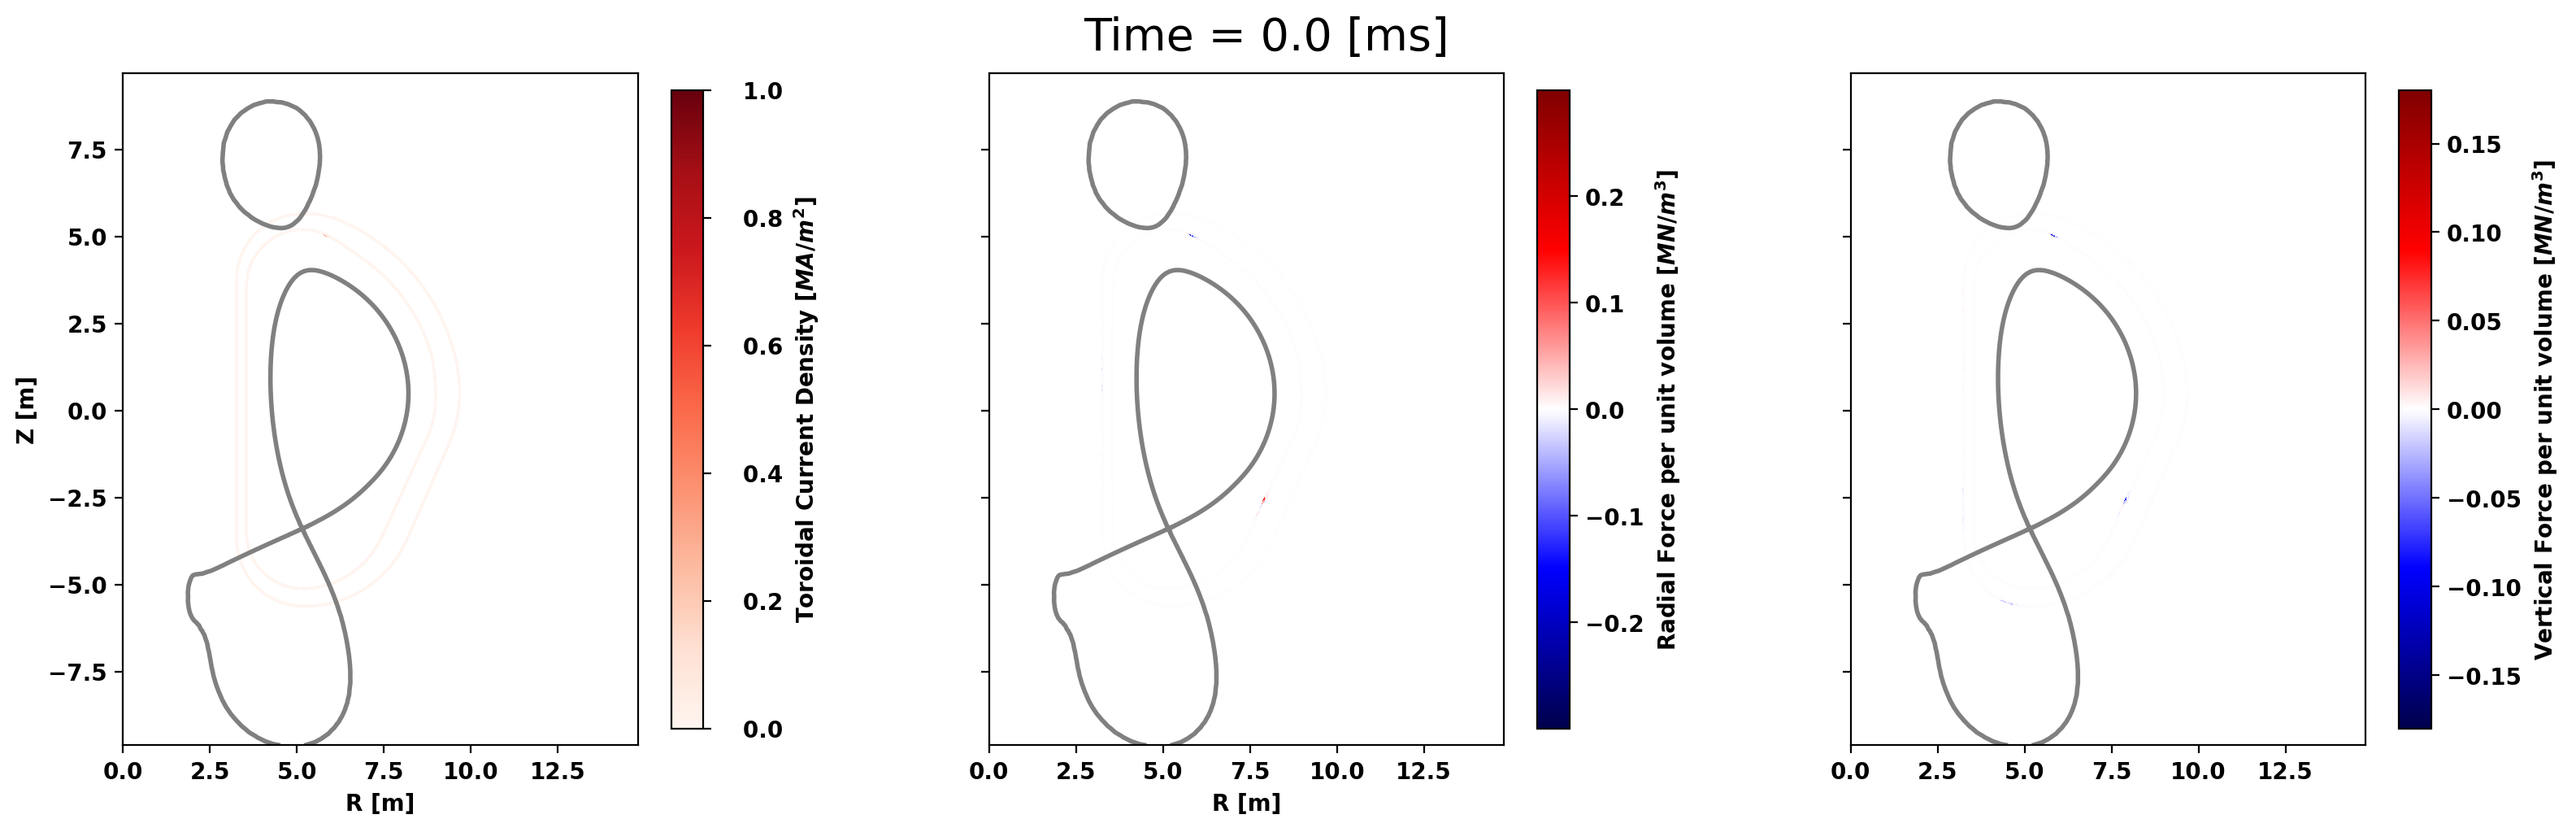

In [17]:
import matplotlib.animation

fig, ax = plt.subplots(1,3,figsize=(16,5),sharey=True,constrained_layout=True)
cbs = [None, None, None]

def animate(ii):
    # Clear figure
    global cbs
    for cb in cbs:
        if cb is not None:
            cb.remove()
    for ax_tmp in ax:
        ax_tmp.clear()

    # Plot time point
    cbs[0], cbs[1], cbs[2] = plot_CQ(fig, ax, results[ii], sim_time[ii])

# Save as GIF
ani = matplotlib.animation.FuncAnimation(fig, animate, frames=40)
ani.save('ITER_CQ.gif',dpi=200,fps=10)